# Стохастическая сеть Петри: трассы, терминальное состояние и цензурирование

Состояния `A, B, C`, терминальное `D`, цензурирование — место `CENS`. Генерируем трассы «жизни» и журнал событий.

## 1. Модель

### 1.1 Сеть

Переходы: вероятность выбора `p` и распределение времени (в днях). Переходы в `CENS` — потеря наблюдения: они не выбираются, а соревнуются по времени с выбранным переходом.

In [1]:
import math
from collections import Counter

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

PLACES = ["A", "B", "C", "D"]
START = "A"      # здесь лежит фишка в момент входа объекта в наблюдение
TERMINAL = "D"   # поглощающее состояние = «событие»

# dist = (тип, параметры); время в днях
TRANSITIONS = [
    dict(name="A→B", src="A", dst="B", p=0.7, dist=("exponential", {"mean": 2.0})),
    dict(name="A→C", src="A", dst="C", p=0.3, dist=("lognormal",   {"median": 5.0, "sigma": 0.5})),
    dict(name="B→A", src="B", dst="A", p=0.2, dist=("uniform",     {"low": 1.0, "high": 3.0})),
    dict(name="B→C", src="B", dst="C", p=0.5, dist=("gamma",       {"shape": 2.0, "scale": 1.5})),
    dict(name="B→D", src="B", dst="D", p=0.3, dist=("weibull",     {"shape": 1.5, "scale": 10.0})),
    dict(name="C→B", src="C", dst="B", p=0.4, dist=("exponential", {"mean": 3.0})),
    dict(name="C→D", src="C", dst="D", p=0.6, dist=("weibull",     {"shape": 0.8, "scale": 6.0})),
]

# Цензурирование (потеря наблюдения) — отдельное место сети.
# Переходы в CENS не выбираются по вероятности, а соревнуются по времени с выбранным переходом.
CENSORED = "CENS"
LOSS_MEAN_DAYS = 60   # среднее время до потери наблюдения; None — потерь нет
CENS_TRANSITIONS = [
    dict(name=f"{p}→{CENSORED}", src=p, dst=CENSORED, dist=("exponential", {"mean": LOSS_MEAN_DAYS}))
    for p in PLACES if p != TERMINAL
] if LOSS_MEAN_DAYS else []

### 1.2 Распределения времени

In [2]:
def sample_time(dist, rng):
    kind, par = dist
    if kind == "exponential":
        return rng.exponential(par["mean"])
    if kind == "lognormal":
        return rng.lognormal(np.log(par["median"]), par["sigma"])
    if kind == "gamma":
        return rng.gamma(par["shape"], par["scale"])
    if kind == "weibull":
        return par["scale"] * rng.weibull(par["shape"])
    if kind == "uniform":
        return rng.uniform(par["low"], par["high"])
    raise ValueError(f"неизвестное распределение: {kind}")


def mean_time(dist):
    kind, par = dist
    if kind == "exponential":
        return par["mean"]
    if kind == "lognormal":
        return par["median"] * math.exp(par["sigma"] ** 2 / 2)
    if kind == "gamma":
        return par["shape"] * par["scale"]
    if kind == "weibull":
        return par["scale"] * math.gamma(1 + 1 / par["shape"])
    if kind == "uniform":
        return (par["low"] + par["high"]) / 2
    raise ValueError(f"неизвестное распределение: {kind}")


def dist_str(dist):
    kind, par = dist
    return kind + "(" + ", ".join(f"{k}={v:g}" for k, v in par.items()) + ")"


pd.DataFrame([{**{k: t[k] for k in ("name", "p")},
               "распределение": dist_str(t["dist"]),
               "E[τ], дней": round(mean_time(t["dist"]), 2)} for t in TRANSITIONS])

  name    p                   распределение  E[τ], дней
0  A→B  0.7             exponential(mean=2)        2.00
1  A→C  0.3  lognormal(median=5, sigma=0.5)        5.67
2  B→A  0.2          uniform(low=1, high=3)        2.00
3  B→C  0.5       gamma(shape=2, scale=1.5)        3.00
4  B→D  0.3    weibull(shape=1.5, scale=10)        9.03
5  C→B  0.4             exponential(mean=3)        3.00
6  C→D  0.6     weibull(shape=0.8, scale=6)        6.80

### 1.3 Проверка сети

Вероятности по каждому месту дают 1, `D` достижимо из любого места.

In [3]:
def validate_net(places, transitions, start, terminal):
    assert start in places and terminal in places
    for t in transitions:
        assert t["src"] in places and t["dst"] in places, f"{t['name']}: неизвестное место"
        assert 0 < t["p"] <= 1, f"{t['name']}: вероятность вне (0, 1]"
    for p in places:
        out = [t["p"] for t in transitions if t["src"] == p]
        if p == terminal:
            assert not out, f"у терминального места {p} есть выходы"
        else:
            assert out, f"из места {p} нет выхода — тупик"
            assert abs(sum(out) - 1) < 1e-9, f"{p}: сумма вероятностей = {sum(out)}"
    reach, frontier = {terminal}, [terminal]
    while frontier:
        q = frontier.pop()
        for t in transitions:
            if t["dst"] == q and t["src"] not in reach:
                reach.add(t["src"])
                frontier.append(t["src"])
    assert reach == set(places), f"{terminal} недостижимо из {set(places) - reach}"
    print("Сеть корректна: вероятности нормированы, терминал достижим из всех мест.")


validate_net(PLACES, TRANSITIONS, START, TERMINAL)

Сеть корректна: вероятности нормированы, терминал достижим из всех мест.


### 1.4 Вероятности с учётом цензурирования

`p` — вероятность выбора, `p факт.` — вероятность, что переход сработает раньше потери наблюдения.

In [4]:
def lose_prob(t, n=100_000, seed=0):
    """P(потеря наблюдения раньше, чем сработает переход t)."""
    if not LOSS_MEAN_DAYS:
        return 0.0
    rng = np.random.default_rng(seed)
    tau = np.array([sample_time(t["dist"], rng) for _ in range(n)])
    return float(np.mean(1 - np.exp(-tau / LOSS_MEAN_DAYS)))


P_LOSE = {t["name"]: lose_prob(t) for t in TRANSITIONS}
P_EFF = {t["name"]: t["p"] * (1 - P_LOSE[t["name"]]) for t in TRANSITIONS}
Q_CENS = {p: sum(t["p"] * P_LOSE[t["name"]] for t in TRANSITIONS if t["src"] == p)
          for p in PLACES if p != TERMINAL}

rows = [{"место": t["src"], "переход": t["name"], "p": t["p"], "p факт.": round(P_EFF[t["name"]], 3)}
        for t in TRANSITIONS]
rows += [{"место": p, "переход": f"{p}→{CENSORED}", "p": "гонка", "p факт.": round(q, 3)}
         for p, q in Q_CENS.items()]
pd.DataFrame(rows).sort_values(["место", "переход"]).reset_index(drop=True)

  место переход      p  p факт.
0     A     A→B    0.7    0.677
1     A     A→C    0.3    0.273
2     A  A→CENS  гонка    0.049
3     B     B→A    0.2    0.193
4     B     B→C    0.5    0.476
5     B  B→CENS  гонка    0.071
6     B     B→D    0.3    0.259
7     C     C→B    0.4    0.381
8     C  C→CENS  гонка    0.078
9     C     C→D    0.6    0.541

### 1.5 Схема сети

В скобках — фактическая вероятность. Пунктир — цензурирование, `q` — вероятность уйти в `CENS`.

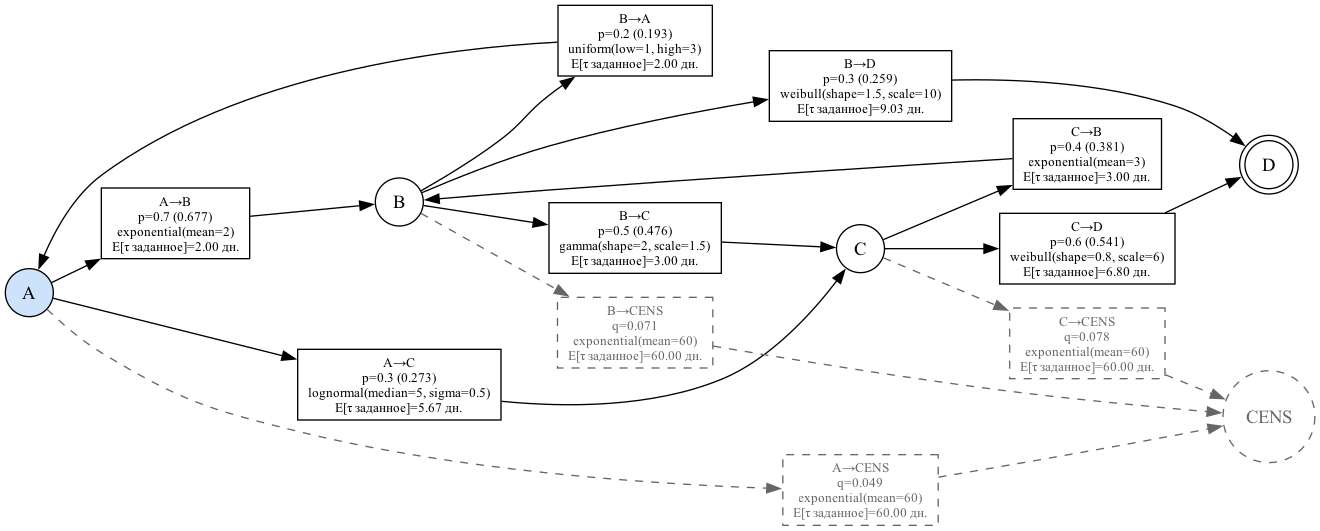

In [5]:
try:
    import graphviz

    g = graphviz.Digraph(graph_attr={"rankdir": "LR"})
    for p in PLACES:
        g.node(p, shape="doublecircle" if p == TERMINAL else "circle",
               style="filled", fillcolor="#cde2fb" if p == START else "white")
    for t in TRANSITIONS:
        g.node(t["name"], shape="box", fontsize="10",
               label=f"{t['name']}\np={t['p']} ({P_EFF[t['name']]:.3f})\n{dist_str(t['dist'])}\nE[τ заданное]={mean_time(t['dist']):.2f} дн.")
        g.edge(t["src"], t["name"])
        g.edge(t["name"], t["dst"])
    if CENS_TRANSITIONS:
        g.node(CENSORED, shape="circle", style="dashed", color="gray40", fontcolor="gray40")
        for t in CENS_TRANSITIONS:
            g.node(t["name"], shape="box", style="dashed", fontsize="10", color="gray40", fontcolor="gray40",
                   label=f"{t['name']}\nq={Q_CENS[t['src']]:.3f}\n{dist_str(t['dist'])}\nE[τ заданное]={mean_time(t['dist']):.2f} дн.")
            g.edge(t["src"], t["name"], style="dashed", color="gray40")
            g.edge(t["name"], CENSORED, style="dashed", color="gray40")
    display(g)
except Exception as e:  # нет пакета graphviz или бинарника dot
    print("graphviz недоступен, рисунок пропущен:", e)

### 1.6 Симуляция одной трассы

`outcome`: `event` — дошли до `D`, `lost` — ушли в `CENS`, `study_end` — закончилось исследование.

In [6]:
def enabled(marking, transitions=TRANSITIONS):
    return [t for t in transitions if marking[t["src"]] >= 1]


def fire(marking, t):
    m = dict(marking)
    m[t["src"]] -= 1
    m[t["dst"]] += 1
    return m


def simulate_case(rng, horizon=np.inf, censoring=True, max_steps=10_000):
    """Возвращает (events, duration, outcome); events = [(состояние, время от старта), ...],
    outcome — "event" (дошли до D), "lost" (фишка ушла в CENS) или "study_end"."""
    marking = {p: 0 for p in PLACES + [CENSORED]}
    marking[START] = 1
    t_now = 0.0
    events = [(START, 0.0)]
    if not censoring:
        horizon = np.inf
    for _ in range(max_steps):
        if marking[TERMINAL]:
            return events, t_now, "event"
        cand = enabled(marking)
        tr = cand[rng.choice(len(cand), p=[c["p"] for c in cand])]  # preselection
        dt = sample_time(tr["dist"], rng)
        if censoring:
            for c in enabled(marking, CENS_TRANSITIONS):             # гонка с потерей наблюдения
                dc = sample_time(c["dist"], rng)
                if dc < dt:
                    tr, dt = c, dc
        if t_now + dt > horizon:
            return events, horizon, "study_end"
        t_now += dt
        marking = fire(marking, tr)
        if marking[CENSORED]:
            return events, t_now, "lost"              # в лог не пишется
        events.append((tr["dst"], t_now))
    raise RuntimeError("превышено max_steps — проверьте достижимость терминала")


rng = np.random.default_rng(1)
for _ in range(5):
    ev, y, outcome = simulate_case(rng, horizon=20)
    print(f"{outcome:>9}  Y={y:6.2f}  " + " → ".join(f"{s}@{t:.1f}" for s, t in ev))

    event  Y=  4.16  A@0.0 → B@0.6 → C@4.1 → D@4.2
    event  Y= 13.80  A@0.0 → B@0.5 → C@4.3 → B@6.4 → C@12.3 → D@13.8
     lost  Y= 14.16  A@0.0
    event  Y=  5.12  A@0.0 → B@3.8 → D@5.1
    event  Y=  8.75  A@0.0 → B@0.1 → D@8.7


### 1.7 Генерация журнала

Объекты входят в исследование в течение `ENROLL_DAYS` дней, исследование длится `STUDY_DAYS` дней.

Каждая запись содержит `transition` — переход, завершившийся входом в данное состояние,
и `duration_days` — его фактическую длительность в днях (время между состояниями).
Для начальной записи `transition="start"`, `duration_days=0`.
Длительность вычисляется до округления временных меток до секунд.
Потеря наблюдения и конец исследования не добавляют событий в лог:
время до цензурирования хранится в таблице трасс как `duration`.

In [7]:
N_CASES = 1000
SEED = 2026
STUDY_START = pd.Timestamp("2025-01-01")
ENROLL_DAYS = 60
STUDY_DAYS = 90


def generate_log(n_cases, seed, study_start, enroll_days, study_days):
    rng = np.random.default_rng(seed)
    event_rows, case_rows = [], []
    for i in range(n_cases):
        case_id = f"case_{i + 1:04d}"
        entry = rng.uniform(0, enroll_days)
        events, duration, outcome = simulate_case(rng, horizon=study_days - entry)
        previous_state, previous_time = None, 0.0
        for state, t in events:
            event_rows.append({
                "case_id": case_id,
                "activity": state,
                "timestamp": study_start + pd.to_timedelta(entry + t, unit="D").round("s"),
                "transition": "start" if previous_state is None else f"{previous_state}→{state}",
                "duration_days": t - previous_time,
            })
            previous_state, previous_time = state, t
        case_rows.append({
            "case_id": case_id,
            "entry": study_start + pd.to_timedelta(entry, unit="D").round("s"),
            "duration": duration,
            "event": int(outcome == "event"),
            "censor_reason": "" if outcome == "event" else outcome,
            "last_state": events[-1][0],
            "n_events": len(events),
        })
    return pd.DataFrame(event_rows), pd.DataFrame(case_rows)


log, cases = generate_log(N_CASES, SEED, STUDY_START, ENROLL_DAYS, STUDY_DAYS)
print(f"{len(cases)} трасс, {len(log)} событий")
print(f"событие D наблюдалось: {cases.event.mean():.1%}")
print("причины цензурирования:", cases.loc[cases.event == 0, "censor_reason"].value_counts().to_dict())
log.head(8)

1000 трасс, 4115 событий
событие D наблюдалось: 80.5%
причины цензурирования: {'lost': 186, 'study_end': 9}


     case_id activity           timestamp transition  duration_days
0  case_0001        A 2025-01-11 17:39:58      start       0.000000
1  case_0001        B 2025-01-12 14:15:06        A→B       0.857732
2  case_0002        A 2025-02-09 04:00:36      start       0.000000
3  case_0002        B 2025-02-12 13:04:45        A→B       3.377877
4  case_0002        C 2025-02-14 21:11:37        B→C       2.338102
5  case_0002        D 2025-02-20 09:18:22        C→D       5.504687
6  case_0003        A 2025-01-14 13:55:11      start       0.000000
7  case_0003        B 2025-01-15 12:39:50        A→B       0.947678

In [8]:
cases.head(8)

,case_id,entry,duration,event,censor_reason,last_state,n_events
0,case_0001,2025-01-11 17:39:58,1.973339,0,lost,B,2
1,case_0002,2025-02-09 04:00:36,11.220665,1,,D,4
2,case_0003,2025-01-14 13:55:11,9.150577,1,,D,6
3,case_0004,2025-02-03 19:15:48,23.446178,1,,D,8
4,case_0005,2025-02-01 03:54:48,25.846312,1,,D,3
5,case_0006,2025-02-13 19:17:35,10.016408,1,,D,3
6,case_0007,2025-02-07 06:08:49,11.908880,1,,D,6
7,case_0008,2025-02-09 13:50:04,6.919399,1,,D,4


## 2. Трассы

### 2.1 Варианты

In [9]:
variants = (log.groupby("case_id")["activity"].agg("".join)
               .to_frame("variant").join(cases.set_index("case_id")["event"]))
top = (variants.groupby("variant")
               .agg(n=("event", "size"), share_with_D=("event", "mean"))
               .sort_values("n", ascending=False))
print(f"уникальных вариантов: {len(top)}")
top.head(12)

уникальных вариантов: 101


,n,share_with_D
variant,,
ABCD,193,1.0
ABD,192,1.0
ACD,145,1.0
A,42,0.0
AB,37,0.0
ABC,31,0.0
ABABCD,26,1.0
ABCBD,26,1.0
ABABD,26,1.0


### 2.2 Длина трасс

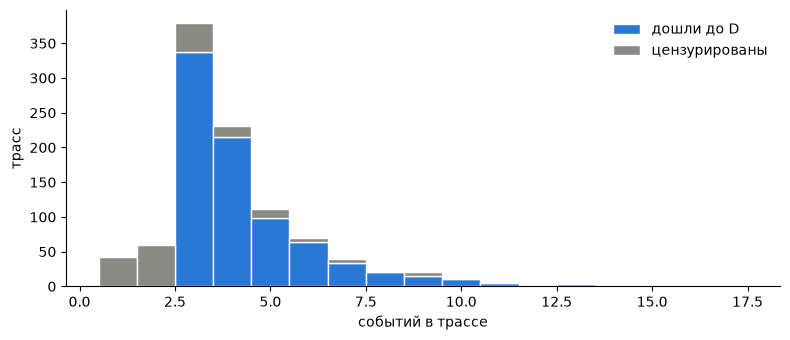

In [10]:
BLUE, ORANGE, AQUA, YELLOW, GRAY = "#2a78d6", "#eb6834", "#1baf7a", "#eda100", "#8a8a85"
STATE_COLOR = {"A": BLUE, "B": ORANGE, "C": AQUA, "D": YELLOW}

fig, ax = plt.subplots(figsize=(8, 3.5))
bins = np.arange(1, cases.n_events.max() + 2) - 0.5
ax.hist([cases.loc[cases.event == 1, "n_events"], cases.loc[cases.event == 0, "n_events"]],
        bins=bins, stacked=True, color=[BLUE, GRAY], edgecolor="white", linewidth=1,
        label=["дошли до D", "цензурированы"])
ax.set_xlabel("событий в трассе")
ax.set_ylabel("трасс")
ax.legend(frameon=False)
ax.spines[["top", "right"]].set_visible(False)
plt.tight_layout()
plt.show()

### 2.3 Таймлайн

Звёздочка — событие `D`, черта — цензурирование.

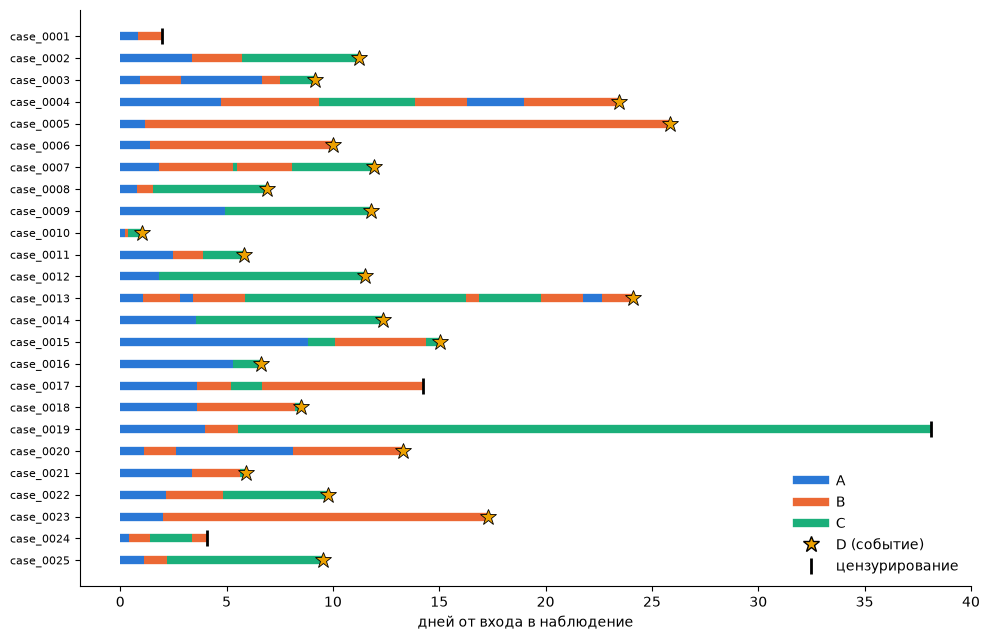

In [11]:
sample_ids = cases.case_id.iloc[:25]
fig, ax = plt.subplots(figsize=(10, 6.5))
for row, cid in enumerate(sample_ids):
    tr = log[log.case_id == cid]
    c = cases.set_index("case_id").loc[cid]
    rel = ((tr.timestamp - c.entry).dt.total_seconds() / 86400).to_numpy()
    ends = np.append(rel[1:], c.duration)
    for state, t0, t1 in zip(tr.activity, rel, ends):
        if state != TERMINAL:
            ax.plot([t0, t1], [row, row], color=STATE_COLOR[state], lw=6, solid_capstyle="butt")
    if c.event:
        ax.plot(c.duration, row, marker="*", ms=12, color=YELLOW, mec="black", mew=0.6)
    else:
        ax.plot(c.duration, row, marker="|", ms=12, mew=2, color="black")
ax.set_yticks(range(len(sample_ids)), sample_ids, fontsize=8)
ax.invert_yaxis()
ax.set_xlabel("дней от входа в наблюдение")
handles = [plt.Line2D([], [], color=STATE_COLOR[s], lw=6, label=s) for s in "ABC"]
handles += [plt.Line2D([], [], ls="", marker="*", ms=12, color=YELLOW, mec="black", label="D (событие)"),
            plt.Line2D([], [], ls="", marker="|", ms=12, mew=2, color="black", label="цензурирование")]
ax.legend(handles=handles, loc="lower right", frameon=False)
ax.spines[["top", "right"]].set_visible(False)
plt.tight_layout()
plt.show()

## 3. Проверки

### 3.1 Частоты переходов

Эталон — симуляция без цензурирования.

In [12]:
rng_truth = np.random.default_rng(7)
truth = [simulate_case(rng_truth, censoring=False) for _ in range(20_000)]
T_true = np.array([y for _, y, _ in truth])


def transition_shares(traces):
    pairs = Counter((a, b) for tr in traces for (a, _), (b, _) in zip(tr, tr[1:]))
    out_tot = Counter()
    for (a, _), n in pairs.items():
        out_tot[a] += n
    return {f"{a}→{b}": n / out_tot[a] for (a, b), n in pairs.items()}


observed = [list(zip(g.activity, g.timestamp)) for _, g in log.groupby("case_id")]
share_true = transition_shares([ev for ev, _, _ in truth])
share_log = transition_shares(observed)
pd.DataFrame([{"переход": t["name"], "задано p": t["p"],
               "симуляция без цензуры": round(share_true.get(t["name"], 0), 3),
               "цензурированный лог": round(share_log.get(t["name"], 0), 3)} for t in TRANSITIONS])

,переход,задано p,симуляция без цензуры,цензурированный лог
0,A→B,0.7,0.699,0.719
1,A→C,0.3,0.301,0.281
2,B→A,0.2,0.199,0.215
3,B→C,0.5,0.504,0.508
4,B→D,0.3,0.296,0.277
5,C→B,0.4,0.402,0.391
6,C→D,0.6,0.598,0.609


### 3.2 Вероятность ухода в `CENS`

In [13]:
rng_q = np.random.default_rng(11)
leave, to_cens = Counter(), Counter()
for _ in range(20_000):
    ev, _, outcome = simulate_case(rng_q)          # horizon = ∞: только потеря наблюдения
    for state, _ in ev:
        if state != TERMINAL:
            leave[state] += 1
    if outcome == "lost":
        to_cens[ev[-1][0]] += 1
pd.DataFrame([{"место": p, "q (формула)": round(q, 3), "q (симуляция)": round(to_cens[p] / leave[p], 3)}
              for p, q in Q_CENS.items()])

,место,q (формула),q (симуляция)
0,A,0.049,0.048
1,B,0.071,0.071
2,C,0.078,0.078


### 3.3 Среднее время до `D`

Формула против симуляции.

In [14]:
transient = [p for p in PLACES if p != TERMINAL]
ix = {p: i for i, p in enumerate(transient)}
Q = np.zeros((len(transient), len(transient)))
s = np.zeros(len(transient))
for t in TRANSITIONS:
    i = ix[t["src"]]
    s[i] += t["p"] * mean_time(t["dist"])
    if t["dst"] != TERMINAL:
        Q[i, ix[t["dst"]]] += t["p"]
m = np.linalg.solve(np.eye(len(transient)) - Q, s)

se = T_true.std() / np.sqrt(len(T_true))
print(f"E[T] аналитически:  {m[ix[START]]:.2f} дней")
print(f"E[T] по симуляции: {T_true.mean():.2f} ± {1.96 * se:.2f} (95% ДИ)")

E[T] аналитически:  15.24 дней
E[T] по симуляции: 15.34 ± 0.14 (95% ДИ)


### 3.4 Кривая выживаемости

Каплан–Майер против истины и двух наивных оценок.

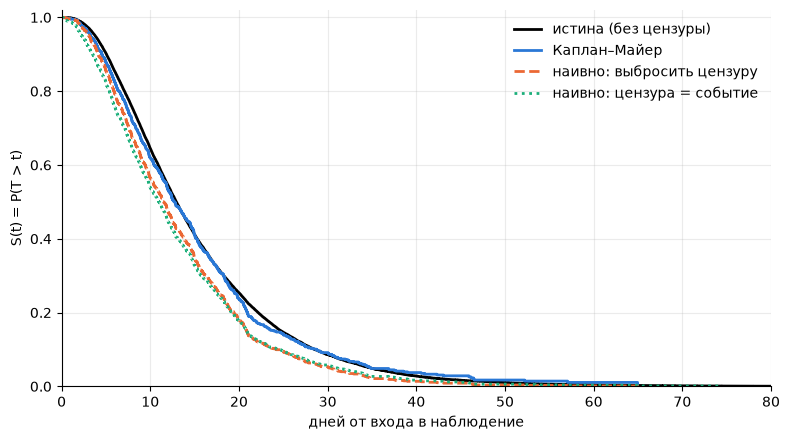

S(10): истина (без цензуры)=0.645, Каплан–Майер=0.620, наивно: выбросить цензуру=0.565, наивно: цензура = событие=0.539
S(20): истина (без цензуры)=0.254, Каплан–Майер=0.237, наивно: выбросить цензуру=0.180, наивно: цензура = событие=0.176
S(40): истина (без цензуры)=0.028, Каплан–Майер=0.037, наивно: выбросить цензуру=0.014, наивно: цензура = событие=0.017


In [15]:
def kaplan_meier(y, d):
    y, d = np.asarray(y), np.asarray(d)
    times = np.unique(y[d == 1])
    surv, s = [], 1.0
    for t in times:
        n_risk = (y >= t).sum()
        n_events = ((y == t) & (d == 1)).sum()
        s *= 1 - n_events / n_risk
        surv.append(s)
    return np.r_[0, times], np.r_[1, surv]


def empirical_surv(y):
    y = np.sort(np.asarray(y))
    return np.r_[0, y], np.r_[1, 1 - np.arange(1, len(y) + 1) / len(y)]


curves = [
    ("истина (без цензуры)", empirical_surv(T_true), "black", "-"),
    ("Каплан–Майер", kaplan_meier(cases.duration, cases.event), BLUE, "-"),
    ("наивно: выбросить цензуру", empirical_surv(cases.duration[cases.event == 1]), ORANGE, "--"),
    ("наивно: цензура = событие", empirical_surv(cases.duration), AQUA, ":"),
]
fig, ax = plt.subplots(figsize=(8, 4.5))
for label, (x, yv), color, ls in curves:
    ax.step(x, yv, where="post", color=color, ls=ls, lw=2, label=label)
ax.set_xlim(0, 80)
ax.set_ylim(0, 1.02)
ax.set_xlabel("дней от входа в наблюдение")
ax.set_ylabel("S(t) = P(T > t)")
ax.legend(frameon=False)
ax.grid(alpha=0.25)
ax.spines[["top", "right"]].set_visible(False)
plt.tight_layout()
plt.show()

for t in (10, 20, 40):
    row = {label: yv[np.searchsorted(x, t, side="right") - 1] for label, (x, yv), _, _ in curves}
    print(f"S({t:>2}): " + ", ".join(f"{k}={v:.3f}" for k, v in row.items()))

## 4. Сохранение

In [8]:
from pathlib import Path

out = Path("output")
out.mkdir(exist_ok=True)
log.to_csv(out / "event_log.csv", index=False)
cases.to_csv(out / "survival_table.csv", index=False)
print("сохранено в", out.resolve())

сохранено в /Users/dimonzhi/Documents/proga/SurvivalProcessMining/notebooks/output


## 5. PM4Py

### 5.1 Загрузка лога

Цензурирование передаётся пользовательскими атрибутами трассы `case:event` и `case:duration`.
Название перехода `transition` и его длительность `duration_days` передаются атрибутами
события, без префикса `case:`. В `EventLog` они доступны как
`trace[i]["transition"]` и `trace[i]["duration_days"]`.
Это дополнительные данные: алгоритмы не начинают автоматически использовать их как веса переходов.

In [9]:
import pm4py
import pm4py.util.constants
from IPython.display import Image

pm4py.util.constants.SHOW_PROGRESS_BAR = False

df = pd.read_csv(out / "event_log.csv", parse_dates=["timestamp"])
surv = pd.read_csv(out / "survival_table.csv")
df = df.merge(surv[["case_id", "event", "duration"]]
                .rename(columns={"event": "case:event", "duration": "case:duration"}),
              on="case_id")
df = pm4py.format_dataframe(df, case_id="case_id", activity_key="activity", timestamp_key="timestamp")
event_log = pm4py.convert_to_event_log(df)
pm4py.write_xes(event_log, str(out / "event_log.xes"))

print("трасс:", len(event_log), " событий:", len(df))
print("стартовые активности:", pm4py.get_start_activities(df))
print("конечные активности: ", pm4py.get_end_activities(df))
df[["case:concept:name", "concept:name", "time:timestamp", "transition", "duration_days", "case:event", "case:duration"]].head()

трасс: 1000  событий: 4115
стартовые активности: {'A': 1000}
конечные активности:  {'B': 62, 'D': 805, 'C': 82, 'A': 51}


  case:concept:name concept:name  ... case:event case:duration
0         case_0001            A  ...          0      1.973339
1         case_0001            B  ...          0      1.973339
2         case_0002            A  ...          1     11.220665
3         case_0002            B  ...          1     11.220665
4         case_0002            C  ...          1     11.220665

[5 rows x 7 columns]

### 5.2 Граф прямых следований (DFG)

Первая диаграмма показывает частоты, вторая — среднее наблюдаемое время между
соседними состояниями. Для времени используются точные `duration_days`,
переведённые в секунды для визуализатора PM4Py (он сам форматирует единицы).
Это время среди наблюдаемых переходов: цензурированные интервалы сюда не входят.


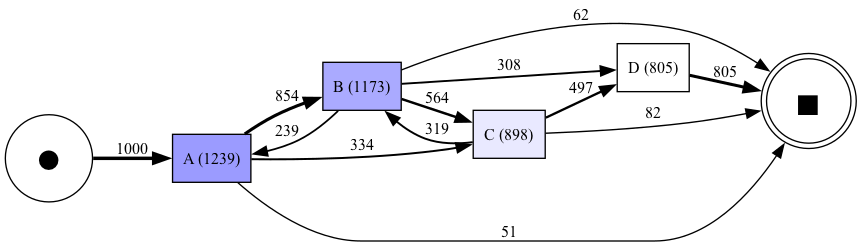

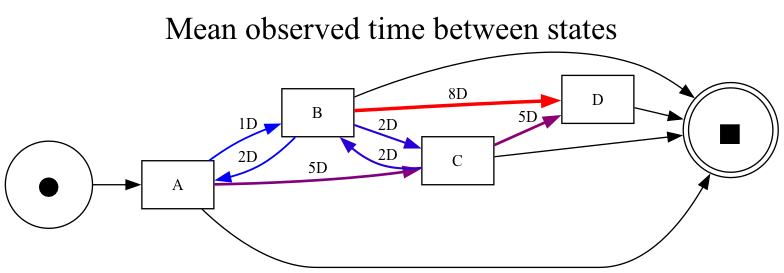

In [10]:
dfg, start_act, end_act = pm4py.discover_dfg(df)
pm4py.save_vis_dfg(dfg, start_act, end_act, str(out / "dfg.png"))
display(Image(str(out / "dfg.png")))

# Строки df уже упорядочены format_dataframe по трассе и времени.
previous_activity = df.groupby("case:concept:name", sort=False)["concept:name"].shift()
observed_steps = df.assign(previous_activity=previous_activity).dropna(subset=["previous_activity"])
mean_days = observed_steps.groupby(["previous_activity", "concept:name"])["duration_days"].mean()
performance_dfg = {edge: float(days * 86400) for edge, days in mean_days.items()}
pm4py.save_vis_performance_dfg(
    performance_dfg, start_act, end_act, str(out / "dfg_performance.png"),
    aggregation_measure="mean",
    graph_title="Mean observed time between states",
)
display(Image(str(out / "dfg_performance.png")))


### 5.3 Исходная модель и проверка соответствия

`choice_probability` — вероятность выбора, `probability` — фактическая. Переходы в `CENS` тихие (τ): в логе нет события «потерян». Цензурированные трассы не доходят до `D`, поэтому fitness < 1.

`E[τ заданное]` на переходах — среднее заданного распределения времени,
до отбора гонкой с цензурированием. Для переходов в `CENS` это среднее таймера
потери наблюдения, а не среднее время среди выигранных им гонок.

сумма фактических вероятностей по местам: {'A': 1.0, 'B': 1.0, 'C': 1.0}


  место переход  choice_probability  probability
3     A     A→B                 0.7        0.677
2     A     A→C                 0.3        0.273
7     A  A→CENS                 NaN        0.049
4     B     B→A                 0.2        0.193
0     B     B→C                 0.5        0.476
8     B  B→CENS                 NaN        0.071
5     B     B→D                 0.3        0.259
1     C     C→B                 0.4        0.381
9     C  C→CENS                 NaN        0.078
6     C     C→D                 0.6        0.541

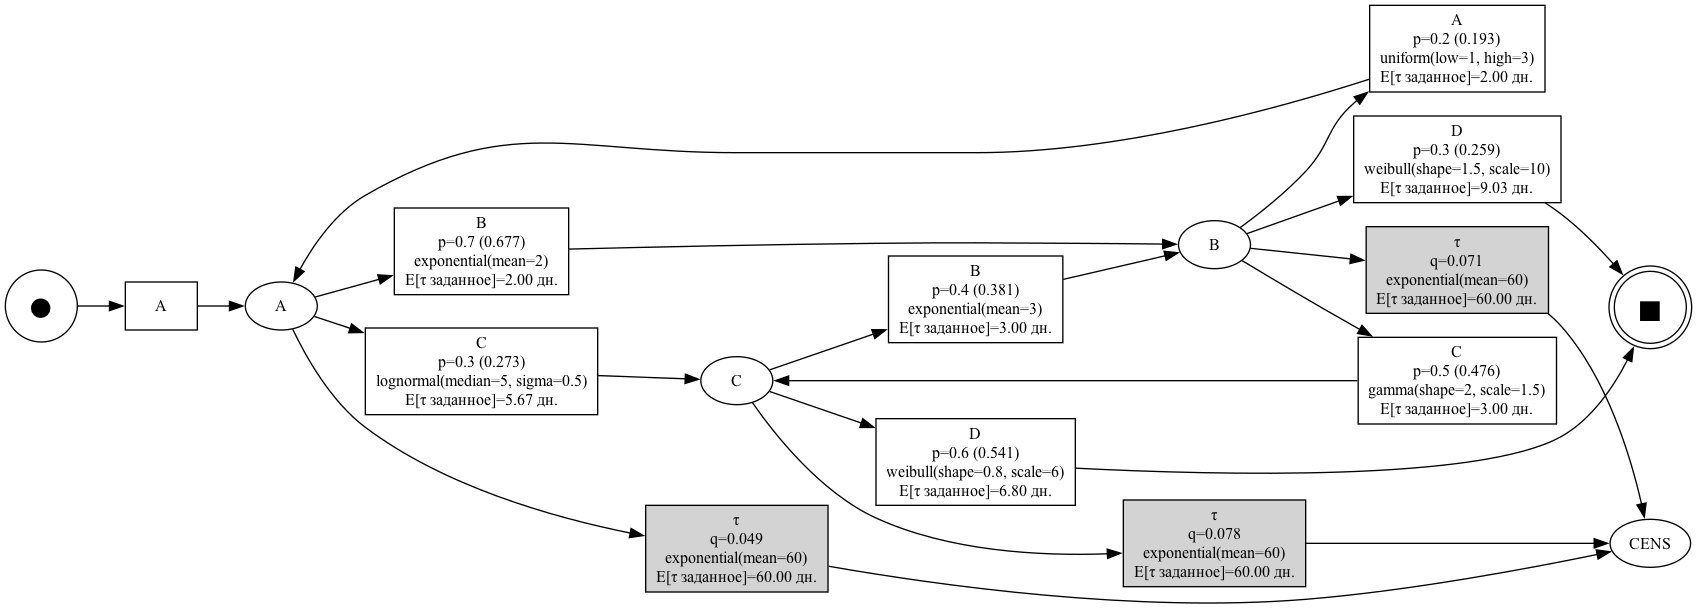

               count      mean  min
event                              
цензурированы    195  0.695125  0.5
дошли до D       805  1.000000  1.0

In [11]:
from pm4py.objects.petri_net.obj import PetriNet, Marking
from pm4py.objects.petri_net.utils import petri_utils

pm_net = PetriNet("stochastic_net")
pm_places = {p: PetriNet.Place(p) for p in ["source"] + PLACES + [CENSORED]}
pm_net.places.update(pm_places.values())


decorations = {pl: {"label": name} for name, pl in pm_places.items() if name != "source"}


def add_transition(name, label, src, dst, choice_p=None, eff_p=1.0, dist=None):
    tr = PetriNet.Transition(name, label)
    tr.properties["choice_probability"] = choice_p   # π(t|p); None — переход участвует в гонке
    tr.properties["probability"] = eff_p             # фактическая вероятность срабатывания
    tr.properties["time_distribution"] = dist
    pm_net.transitions.add(tr)
    petri_utils.add_arc_from_to(pm_places[src], tr, pm_net)
    petri_utils.add_arc_from_to(tr, pm_places[dst], pm_net)
    if dist is not None:
        decorations[tr] = {"label": f"{label}\np={choice_p} ({eff_p:.3f})\n{dist_str(dist)}\nE[τ заданное]={mean_time(dist):.2f} дн." if label
                                    else f"τ\nq={eff_p:.3f}\n{dist_str(dist)}\nE[τ заданное]={mean_time(dist):.2f} дн.",
                           "color": "white" if label else "lightgray"}


add_transition("start", START, "source", START)   # вход в наблюдение: p=1, мгновенно
for t in TRANSITIONS:
    add_transition(t["name"], t["dst"], t["src"], t["dst"], t["p"], P_EFF[t["name"]], t["dist"])
for t in CENS_TRANSITIONS:                          # тихие переходы в CENS
    add_transition(t["name"], None, t["src"], t["dst"], None, Q_CENS[t["src"]], t["dist"])
im = Marking({pm_places["source"]: 1})
fm = Marking({pm_places[TERMINAL]: 1})

props = pd.DataFrame([{"место": next(iter(tr.in_arcs)).source.name, "переход": tr.name,
                       "choice_probability": tr.properties["choice_probability"],
                       "probability": tr.properties["probability"]}
                      for tr in pm_net.transitions if tr.name != "start"]).sort_values(["место", "переход"])
display(props.round(3))
print("сумма фактических вероятностей по местам:", props.groupby("место")["probability"].sum().round(6).to_dict())
pm4py.save_vis_petri_net(pm_net, im, fm, str(out / "model_pm4py.png"), decorations=decorations)
display(Image(str(out / "model_pm4py.png")))

replay = pm4py.conformance_diagnostics_token_based_replay(event_log, pm_net, im, fm)
fit = pd.DataFrame({"case_id": [tr.attributes["concept:name"] for tr in event_log],
                    "event": [tr.attributes["event"] for tr in event_log],
                    "fitness": [r["trace_fitness"] for r in replay]})
fit.groupby("event")["fitness"].agg(["count", "mean", "min"]).rename(index={0: "цензурированы", 1: "дошли до D"})

### 5.4 Inductive Miner

Модель по всему логу и только по полным трассам.

Подпись `ср. до входа` — среднее `duration_days` среди записанных входов в данную
активность, без начальных записей `start`. Это общая статистика по метке активности,
а не оценка времени отдельного восстановленного перехода; одинаковые метки получают
одинаковые подписи. Тихим переходам время не приписывается.
Для модели по полным трассам средние вычисляются только по полным трассам.

              весь лог: переходов 19, из них τ 15, fitness на всём логе 1.000
  только полные трассы: переходов 14, из них τ 10, fitness на всём логе 0.944


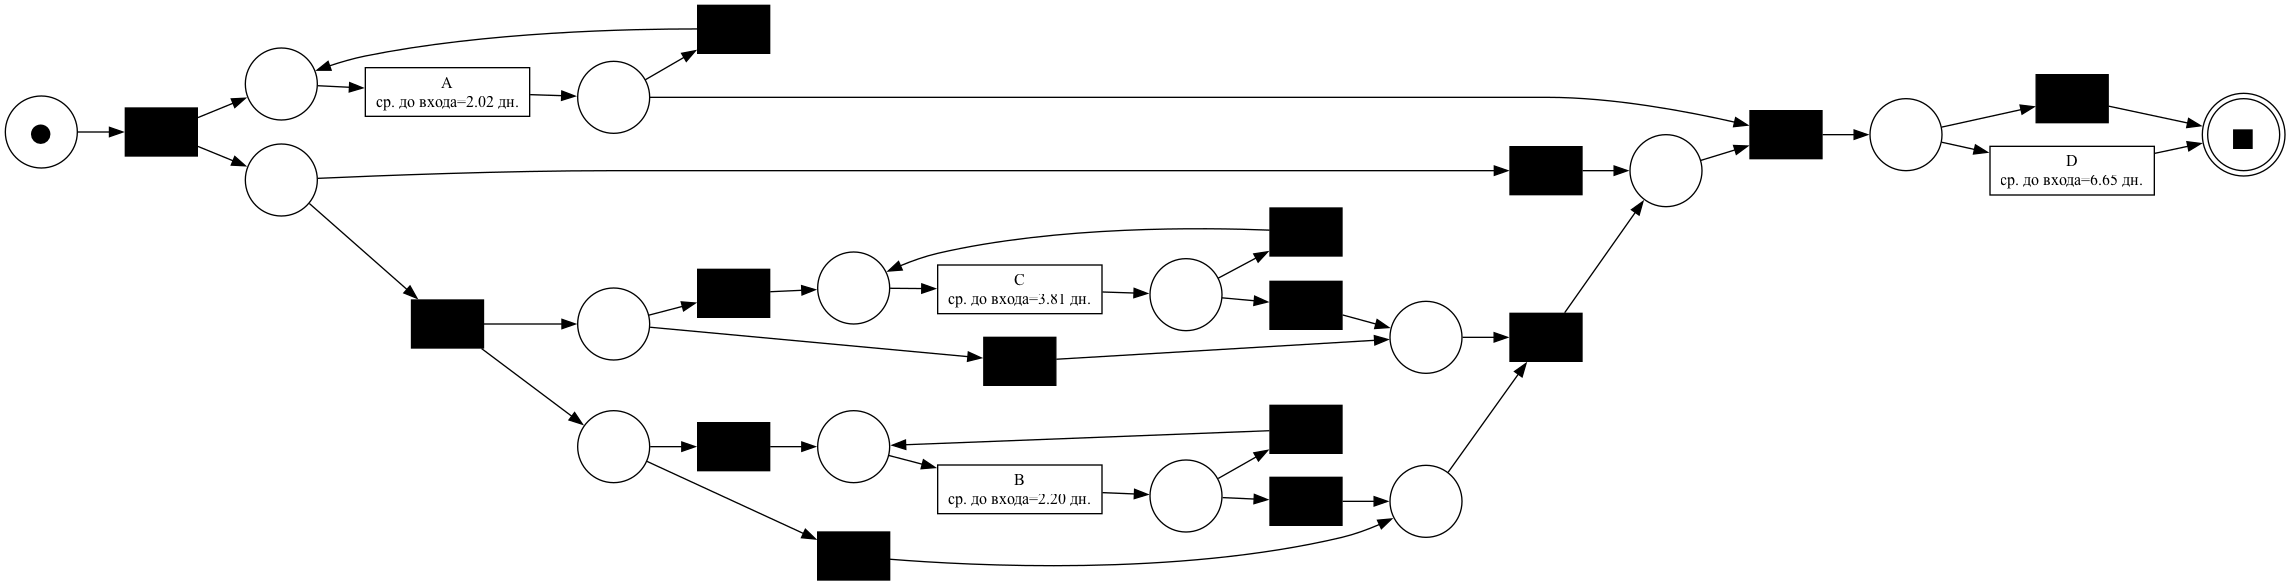

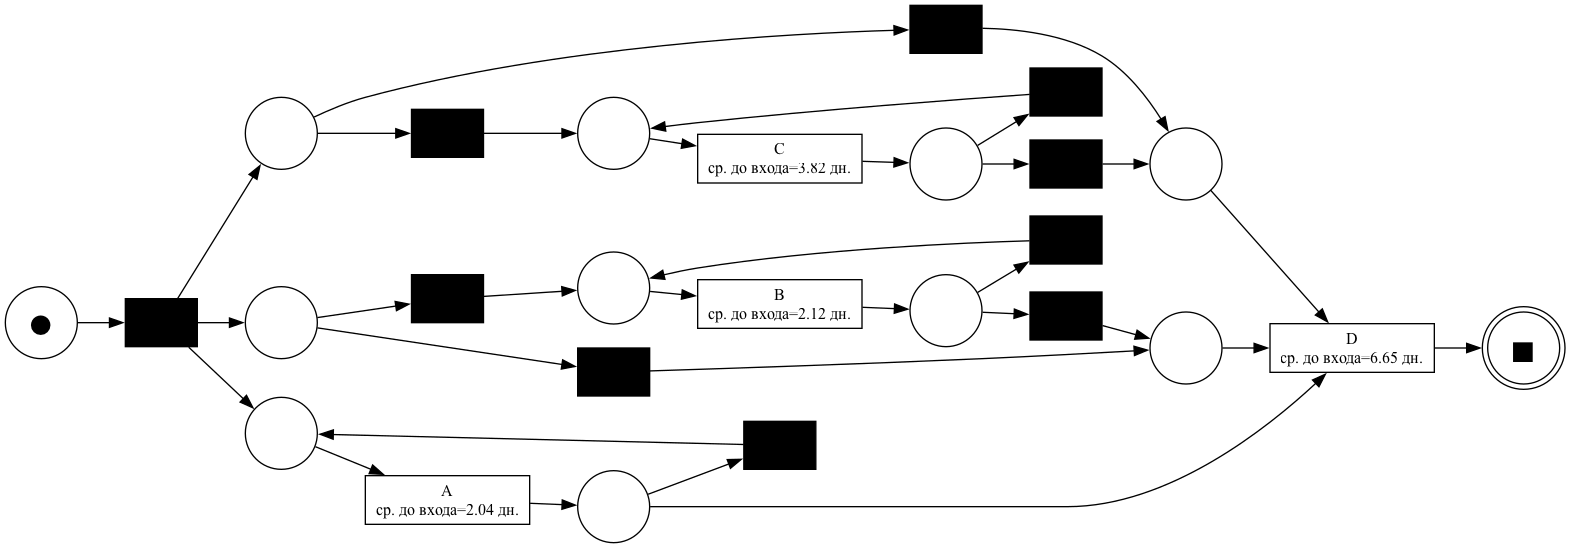

In [12]:
def activity_time_decorations(net, frame):
    means = (frame.loc[frame["transition"] != "start"]
             .groupby("concept:name")["duration_days"].mean())
    return {
        tr: {"label": f"{tr.label}\nср. до входа={means[tr.label]:.2f} дн.", "color": "white"}
        for tr in net.transitions if tr.label is not None and tr.label in means.index
    }


im_net, im_im, im_fm = pm4py.discover_petri_net_inductive(event_log)
pm4py.save_vis_petri_net(im_net, im_im, im_fm, str(out / "discovered_inductive.png"),
                        decorations=activity_time_decorations(im_net, df))
display(Image(str(out / "discovered_inductive.png")))

complete_log = pm4py.filter_trace_attribute_values(event_log, "event", [1])
im_net_c, im_im_c, im_fm_c = pm4py.discover_petri_net_inductive(complete_log)
pm4py.save_vis_petri_net(
    im_net_c, im_im_c, im_fm_c, str(out / "discovered_inductive_complete.png"),
    decorations=activity_time_decorations(im_net_c, df.loc[df["case:event"] == 1]),
)
display(Image(str(out / "discovered_inductive_complete.png")))
for name, (n, i, f) in {"весь лог": (im_net, im_im, im_fm),
                        "только полные трассы": (im_net_c, im_im_c, im_fm_c)}.items():
    fit_all = pm4py.fitness_token_based_replay(event_log, n, i, f)["average_trace_fitness"]
    print(f"{name:>22}: переходов {len(n.transitions):2d}, "
          f"из них τ {sum(t.label is None for t in n.transitions):2d}, "
          f"fitness на всём логе {fit_all:.3f}")

## 6. Что можно менять

* сеть — раздел 1.1 (`TRANSITIONS`, `LOSS_MEAN_DAYS`);
* наблюдение — раздел 1.7 (`N_CASES`, `ENROLL_DAYS`, `STUDY_DAYS`, `SEED`).